# 04 - M: Pemodelan
**Kelompok 12 - Pariwisata Daerah Jawa Barat**

Dua model analitik:
1. **Model 1** — K-Means Clustering kawasan wisata alam 
2. **Model 2** — Regresi Linear faktor yang mempengaruhi TPK hotel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
BG_COLOR       = '#0d1117'
PRIMARY_COLOR  = '#00B4D8'
ACCENT_COLOR   = '#FF6B35'
GREEN_COLOR    = '#2ECC71'
PURPLE_COLOR   = '#9B59B6'
DPI            = 150
OUTPUT_DIR     = '../outputs/figures/'

CLUSTER_COLORS = ['#00B4D8', '#FF6B35', '#2ECC71', '#9B59B6', '#F1C40F']

---
## Dataset yang Digunakan

**1. Wisata Alam** *(dataset utama)* — `data/clean/dishut_clean_v2.csv`
Jumlah pengunjung per kawasan wisata alam | 296 kawasan | 2016–2022
Dipakai di **Model 1** (K-Means) → fitur: `avg_pengunjung`, `years_active`, `rasio_wisman`, `tipe_pengelola`

**2. Hotel TPK** *(dataset pendukung)* — `data/preprocessed/hotel_scrubbed.csv`
Tingkat Penghunian Kamar (TPK) hotel per bulan | 3 jenis hotel | Jan 2019–Des 2025
Dipakai di **Model 2** (Regresi) → fitur: `tahun_norm`, `sin_bulan`, `cos_bulan`, `is_covid_int`



In [ ]:
dishut = pd.read_csv('../data/clean/dishut_clean_v2.csv')
hotel  = pd.read_csv('../data/preprocessed/hotel_scrubbed.csv')
hotel['is_covid'] = hotel['is_covid'].astype(str).str.lower() == 'true'

print(f'Wisata Alam : {dishut.shape[0]} baris x {dishut.shape[1]} kolom')
print(f'Hotel       : {hotel.shape[0]} baris x {hotel.shape[1]} kolom')

---
## Model 1: K-Means Clustering Kawasan Wisata Alam

**Tujuan:** Mengelompokkan kawasan wisata alam berdasarkan performa kunjungan untuk mengidentifikasi kawasan 'bintang aktif', 'andalan lokal', 'potensi tersembunyi', dan 'perlu evaluasi'.

**Input features:**
- `avg_pengunjung` — rata-rata pengunjung per tahun (hanya tahun normal)
- `years_active` — konsistensi pelaporan (berapa tahun aktif dari 5 tahun normal)
- `rasio_wisman` — proporsi wisatawan mancanegara
- `tipe_pengelola` — jenis pengelola kawasan (encoded)

In [3]:
# Hanya gunakan tahun dengan data berkualitas (NORMAL)
NORMAL_YEARS = [2016, 2017, 2018, 2019, 2021]
df_normal = dishut[dishut['tahun'].isin(NORMAL_YEARS)].copy()

# Total pengunjung per kawasan per tahun (gabung wisman + wisnus)
yearly = (df_normal.groupby(['pengelola_kawasan', 'tahun'])['jumlah_wisatawan']
          .sum().reset_index())

# years_active: berapa tahun kawasan melaporkan > 0 pengunjung
years_active = (yearly[yearly['jumlah_wisatawan'] > 0]
                .groupby('pengelola_kawasan')['tahun'].nunique()
                .rename('years_active'))

# avg_pengunjung: total / 5 tahun normal
avg_pengunjung = (df_normal.groupby('pengelola_kawasan')['jumlah_wisatawan']
                  .sum() / len(NORMAL_YEARS)).rename('avg_pengunjung')

# rasio_wisman
wisman = (df_normal[df_normal['jenis_wisatawan'] == 'WISATAWAN MANCANEGARA']
          .groupby('pengelola_kawasan')['jumlah_wisatawan'].sum())
total_all = df_normal.groupby('pengelola_kawasan')['jumlah_wisatawan'].sum()
rasio_wisman = (wisman / total_all.replace(0, np.nan)).fillna(0).rename('rasio_wisman')

# tipe_pengelola
tipe = dishut.groupby('pengelola_kawasan')['tipe_pengelola'].first()

# Gabungkan dan filter kawasan aktif
features1 = pd.concat([avg_pengunjung, years_active, rasio_wisman, tipe], axis=1).reset_index()
features1 = features1[features1['years_active'] > 0].reset_index(drop=True)

print(f'Jumlah kawasan aktif : {len(features1)}')
print(f'\nDistribusi tipe pengelola:')
print(features1['tipe_pengelola'].value_counts().to_string())
print(f'\nStatistik fitur utama:')
print(features1[['avg_pengunjung', 'years_active', 'rasio_wisman']].describe().round(2).to_string())

Jumlah kawasan aktif : 71

Distribusi tipe pengelola:
LAINNYA      42
TWA          14
PERHUTANI     8
TN            5
TAHURA        2

Statistik fitur utama:
       avg_pengunjung  years_active  rasio_wisman
count           71.00         71.00         71.00
mean         12969.99          1.76          0.00
std          42960.25          1.15          0.01
min              0.20          1.00          0.00
25%            222.50          1.00          0.00
50%           1834.20          1.00          0.00
75%           7889.50          2.50          0.00
max         337775.20          4.00          0.08


In [4]:
# Encode tipe_pengelola
le = LabelEncoder()
features1['tipe_enc'] = le.fit_transform(features1['tipe_pengelola'])

enc_map = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
print(f'Label encoding: {enc_map}')

# Normalisasi fitur
feat_cols_1 = ['avg_pengunjung', 'years_active', 'rasio_wisman', 'tipe_enc']
X1 = features1[feat_cols_1].values.copy()
scaler1 = MinMaxScaler()
X1_scaled = scaler1.fit_transform(X1)

print(f'Shape matrix fitur: {X1_scaled.shape}')

Label encoding: {'LAINNYA': 0, 'PERHUTANI': 1, 'TAHURA': 2, 'TN': 3, 'TWA': 4}
Shape matrix fitur: (71, 4)


In [ ]:
# Elbow Method + Silhouette Score
inertias1   = []
sil_scores1 = []
K_range1    = range(2, 9)

for k in K_range1:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X1_scaled)
    inertias1.append(km.inertia_)
    sil_scores1.append(silhouette_score(X1_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

axes[0].plot(list(K_range1), inertias1, 'o-', color=PRIMARY_COLOR, linewidth=2, markersize=8)
axes[0].set_title('Elbow Method - Kawasan Wisata Alam', fontsize=13)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.2)

axes[1].plot(list(K_range1), sil_scores1, 's-', color=ACCENT_COLOR, linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score - Kawasan Wisata Alam', fontsize=13)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.2)

best_k1 = list(K_range1)[sil_scores1.index(max(sil_scores1))]
axes[1].axvline(best_k1, color='yellow', linestyle='--', alpha=0.7,
                label=f'k={best_k1} (silhouette tertinggi)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model1_elbow_wisataalam.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()

sil_dict1 = {k: round(s, 3) for k, s in zip(K_range1, sil_scores1)}
print(f'Silhouette scores : {sil_dict1}')
print(f'k terbaik (sil)   : {best_k1}')

In [6]:
# Fit K-Means final
# k=4 agar sesuai dengan interpretasi kuadran (sehat/kritis/dll)
# Sesuaikan jika silhouette menyarankan k berbeda
K1 = 4

km1 = KMeans(n_clusters=K1, random_state=42, n_init=10)
features1['cluster'] = km1.fit_predict(X1_scaled)

sil1 = silhouette_score(X1_scaled, features1['cluster'])
print(f'Model 1 K-Means: k={K1}')
print(f'Silhouette Score : {sil1:.4f}')
print(f'\nDistribusi cluster:')
print(features1['cluster'].value_counts().sort_index().to_string())

Model 1 K-Means: k=4
Silhouette Score : 0.6686

Distribusi cluster:
0    45
1    13
2     5
3     8


In [7]:
# Profil cluster untuk memberi nama
profile1 = features1.groupby('cluster').agg(
    n_kawasan=('pengelola_kawasan', 'count'),
    avg_pengunjung=('avg_pengunjung', 'mean'),
    years_active=('years_active', 'mean'),
    rasio_wisman_pct=('rasio_wisman', lambda x: round(x.mean() * 100, 2)),
    tipe_dominan=('tipe_pengelola', lambda x: x.mode()[0])
).round(1)

print('=== Profil Rata-rata Tiap Cluster ===')
print(profile1.to_string())
print('\nTop 3 kawasan per cluster (avg_pengunjung tertinggi):')
for c in sorted(features1['cluster'].unique()):
    top3 = features1[features1['cluster'] == c].nlargest(3, 'avg_pengunjung')
    names = ', '.join(top3['pengelola_kawasan'].tolist())
    print(f'  Cluster {c}: {names}')

=== Profil Rata-rata Tiap Cluster ===
         n_kawasan  avg_pengunjung  years_active  rasio_wisman_pct tipe_dominan
cluster                                                                        
0               45          3822.4           1.1               0.1      LAINNYA
1               13         50767.6           3.7               1.3          TWA
2                5          3108.0           3.4               0.4      LAINNYA
3                8          9167.8           1.2               0.1          TWA

Top 3 kawasan per cluster (avg_pengunjung tertinggi):
  Cluster 0: CURUG CISUREN, WH CURUG CILEMBER, CURUG CIGENTIS
  Cluster 1: TWA TANGKUBANPARAHU, TAHURA IR. H. DJUANDA, BALAI TN. GN. CIREMAI
  Cluster 2: CURUG CIMAHI, CITUMANG, TB MASIGIT KAREUMBI
  Cluster 3: BALAI BESAR TN.GN. GEDEPANGRANGO, BALAI TN.GN.HALIMUN-SALAK, TWA LINGGARJATI


In [ ]:
# Visualisasi cluster: avg_pengunjung vs years_active
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

CLUSTER_LABELS = {
    0: 'Perlu Evaluasi',
    1: 'Unggulan Terkelola',
    2: 'Andalan Lokal',
    3: 'Potensi Tersembunyi'
}

for c in sorted(features1['cluster'].unique()):
    subset = features1[features1['cluster'] == c]
    ax.scatter(subset['avg_pengunjung'], subset['years_active'],
               color=CLUSTER_COLORS[c], s=80, alpha=0.75,
               label=f'Cluster {c}: {CLUSTER_LABELS[c]} (n={len(subset)})', zorder=3)

# Annotasi top 6 kawasan
top_kawasan = features1.nlargest(6, 'avg_pengunjung')
x_range = features1['avg_pengunjung'].max() - features1['avg_pengunjung'].min()
for _, row in top_kawasan.iterrows():
    c = int(row['cluster'])
    ax.annotate(
        row['pengelola_kawasan'],
        xy=(row['avg_pengunjung'], row['years_active']),
        xytext=(float(row['avg_pengunjung']) + x_range * 0.01, float(row['years_active']) + 0.1),
        color=CLUSTER_COLORS[c], fontsize=7
    )

med_x = features1['avg_pengunjung'].median()
med_y = features1['years_active'].median()
ax.axvline(med_x, color='white', linestyle='--', alpha=0.2)
ax.axhline(med_y, color='white', linestyle='--', alpha=0.2)

ax.set_title(f'K-Means Clustering Kawasan Wisata Alam Jawa Barat (k={K1})', fontsize=15, pad=20)
ax.set_xlabel('Rata-rata Pengunjung per Tahun (Tahun Normal)')
ax.set_ylabel('Jumlah Tahun Aktif Melaporkan (Maks 5)')
ax.set_yticks(range(0, 6))
ax.legend(title='Cluster', loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.15)
plt.figtext(0.05, 0.01,
            f'Silhouette Score = {sil1:.4f} | Fitur: avg_pengunjung, years_active, rasio_wisman, tipe_pengelola',
            color='gray', fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}model1_cluster_wisataalam.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: model1_cluster_wisataalam.png')

**Interpretasi Model 1 — Hasil Aktual (Silhouette = 0.6686):**

| Cluster | Label | n | Ciri Utama |
|---------|-------|---|------------|
| **0** | **Perlu Evaluasi** | 45 | Mayoritas kawasan LAINNYA; avg 3.8K pengunjung/tahun; hanya aktif 1 tahun dari 5; hampir tidak ada wisman |
| **1** | **Unggulan Terkelola** | 13 | Dikelola TN/TWA/TAHURA; avg 50.8K pengunjung/tahun; konsisten 3–4 tahun; top: Tangkubanparahu (337K), TAHURA Djuanda (114K) |
| **2** | **Andalan Lokal** | 5 | Kawasan LAINNYA tetapi konsisten melapor (3–4 tahun); avg 3.1K; 100% wisnus; ex: Curug Cimahi, Citumang |
| **3** | **Potensi Tersembunyi** | 8 | Status pengelolaan formal (TN/TWA) tetapi pelaporan tidak konsisten (1–2 tahun); avg 9.2K; ex: TN Gede Pangrango, TN Halimun-Salak |

**Catatan:** Cluster terbentuk lebih dipengaruhi oleh `tipe_pengelola` + `years_active` daripada sekadar volume kunjungan, karena distribusi `avg_pengunjung` sangat skewed (1 kawasan dominan: Tangkubanparahu).

---
## Model 2: Regresi Linear — Tingkat Penghunian Kamar (TPK) Hotel

**Tujuan:** Memprediksi TPK hotel Jawa Barat berdasarkan faktor waktu dan dampak COVID-19, serta mengidentifikasi variabel yang paling berpengaruh.

**Dataset:** `hotel_scrubbed.csv` (2019–2025, 84 bulan per jenis hotel)

**Input features:**
- `tahun_norm` — tahun dinormalisasi (tahun − 2019) → menangkap tren jangka panjang
- `sin_bulan` / `cos_bulan` — encoding siklus bulan → menangkap pola musiman
- `is_covid_int` — dummy variabel COVID (1 = periode COVID, 0 = normal)

**Target:** `tpk` (Tingkat Penghunian Kamar, %)

**Strategi split:** Temporal — train 2019–2024, test 2025

In [9]:
# Fokus pada Hotel Berbintang dan NonBintang Total (gabungan) 
TARGET_JENIS = '3. Hotel Berbintang dan NonBintang Total'
df_hotel = hotel[hotel['jenis_hotel'] == TARGET_JENIS].copy()
df_hotel = df_hotel.sort_values(['tahun', 'bulan_num']).reset_index(drop=True)

# Feature engineering
df_hotel['tahun_norm']  = df_hotel['tahun'] - 2019
df_hotel['sin_bulan']   = np.sin(2 * np.pi * df_hotel['bulan_num'] / 12)
df_hotel['cos_bulan']   = np.cos(2 * np.pi * df_hotel['bulan_num'] / 12)
df_hotel['is_covid_int'] = df_hotel['is_covid'].astype(int)

print(f'Total data: {len(df_hotel)} baris ({df_hotel["tahun"].min()}–{df_hotel["tahun"].max()})')
print(f'Periode COVID (is_covid=1): {df_hotel["is_covid_int"].sum()} bulan')
print(f'\nPreview fitur:')
print(df_hotel[['tahun', 'bulan_num', 'tpk', 'tahun_norm', 'sin_bulan', 'cos_bulan', 'is_covid_int']].head(6).to_string(index=False))

Total data: 84 baris (2019–2025)
Periode COVID (is_covid=1): 24 bulan

Preview fitur:
 tahun  bulan_num   tpk  tahun_norm    sin_bulan     cos_bulan  is_covid_int
  2019          1 51.45           0 5.000000e-01  8.660254e-01             0
  2019          2 48.08           0 8.660254e-01  5.000000e-01             0
  2019          3 48.81           0 1.000000e+00  6.123234e-17             0
  2019          4 49.19           0 8.660254e-01 -5.000000e-01             0
  2019          5 36.47           0 5.000000e-01 -8.660254e-01             0
  2019          6 47.57           0 1.224647e-16 -1.000000e+00             0


In [10]:
# Temporal split: train 2019-2024, test 2025
FEAT_COLS_2 = ['tahun_norm', 'sin_bulan', 'cos_bulan', 'is_covid_int']

train = df_hotel[df_hotel['tahun'] <= 2024].copy()
test  = df_hotel[df_hotel['tahun'] == 2025].copy()

X_train = train[FEAT_COLS_2].values
y_train = train['tpk'].values
X_test  = test[FEAT_COLS_2].values
y_test  = test['tpk'].values

# Fit model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Prediksi
y_pred_train = reg.predict(X_train)
y_pred_test  = reg.predict(X_test)

# Metrik
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)

print('=== Model 2: Regresi Linear TPK Hotel ===')
print(f'Train : 2019–2024  ({len(train)} bulan)')
print(f'Test  : 2025       ({len(test)} bulan)')
print(f'\nR² (train) : {r2_train:.4f}')
print(f'R² (test)  : {r2_test:.4f}')
print(f'RMSE (test): {rmse_test:.4f}')
print(f'MAE  (test): {mae_test:.4f}')
print(f'\nIntercept  : {reg.intercept_:.4f}')
for feat, coef in zip(FEAT_COLS_2, reg.coef_):
    print(f'  {feat:15s}: {coef:+.4f}')

=== Model 2: Regresi Linear TPK Hotel ===
Train : 2019–2024  (72 bulan)
Test  : 2025       (12 bulan)

R² (train) : 0.5133
R² (test)  : 0.1066
RMSE (test): 4.4965
MAE  (test): 3.3049

Intercept  : 47.5041
  tahun_norm     : -1.6288
  sin_bulan      : -1.1783
  cos_bulan      : +4.3560
  is_covid_int   : -12.5259


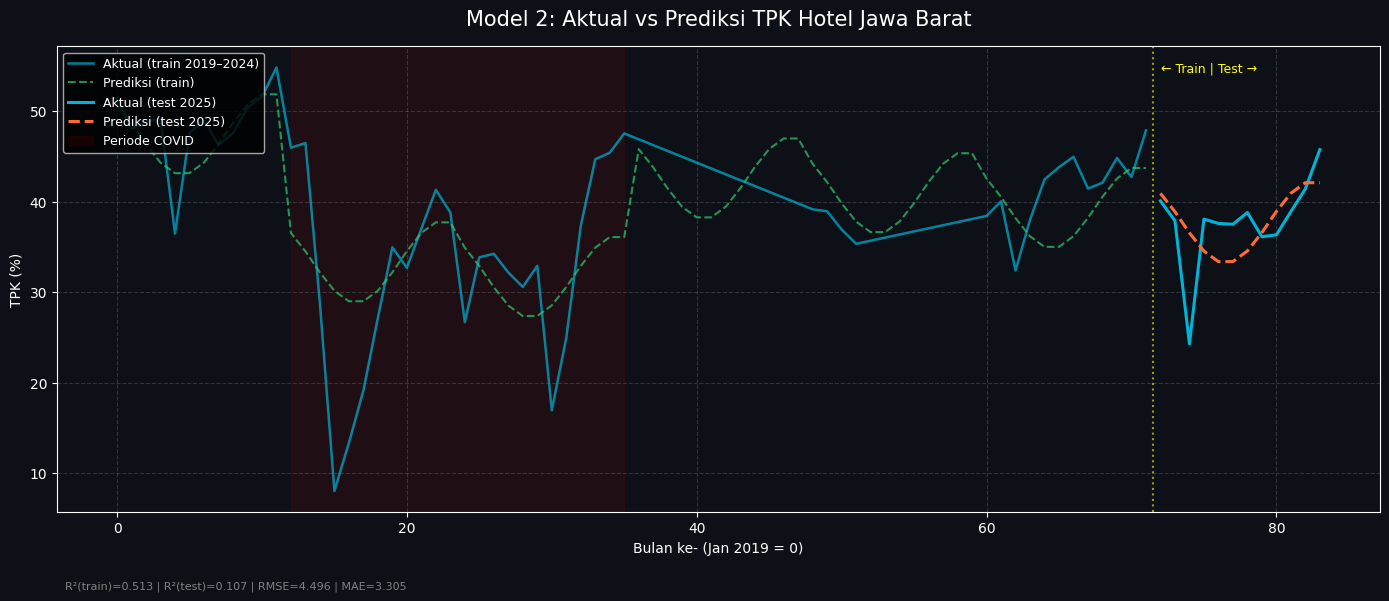

Saved: model2_reg_aktual_vs_prediksi.png


In [11]:
# Visualisasi 1: Aktual vs Prediksi
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Buat timeline (index bulan urut)
all_dates = list(range(len(train))) 
test_dates = list(range(len(train), len(train) + len(test)))

ax.plot(all_dates, y_train, color=PRIMARY_COLOR, linewidth=1.8, alpha=0.7, label='Aktual (train 2019–2024)')
ax.plot(all_dates, y_pred_train, color=GREEN_COLOR, linewidth=1.5, linestyle='--', alpha=0.7, label='Prediksi (train)')
ax.plot(test_dates, y_test, color=PRIMARY_COLOR, linewidth=2.2, label='Aktual (test 2025)')
ax.plot(test_dates, y_pred_test, color=ACCENT_COLOR, linewidth=2.2, linestyle='--', label='Prediksi (test 2025)')

# Garis pemisah train/test
ax.axvline(len(train) - 0.5, color='yellow', linestyle=':', alpha=0.6, linewidth=1.5)
ax.text(len(train) - 0.5, ax.get_ylim()[1] * 0.97, '  ← Train | Test →',
        color='yellow', fontsize=9, va='top')

# Shading COVID
covid_idx = train[train['is_covid_int'] == 1].index
if len(covid_idx) > 0:
    ax.axvspan(covid_idx[0], covid_idx[-1], alpha=0.08, color='red', label='Periode COVID')

ax.set_title('Model 2: Aktual vs Prediksi TPK Hotel Jawa Barat', fontsize=15, pad=15)
ax.set_xlabel('Bulan ke- (Jan 2019 = 0)')
ax.set_ylabel('TPK (%)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.15)
plt.figtext(0.05, 0.01,
            f'R²(train)={r2_train:.3f} | R²(test)={r2_test:.3f} | RMSE={rmse_test:.3f} | MAE={mae_test:.3f}',
            color='gray', fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}model2_reg_aktual_vs_prediksi.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: model2_reg_aktual_vs_prediksi.png')

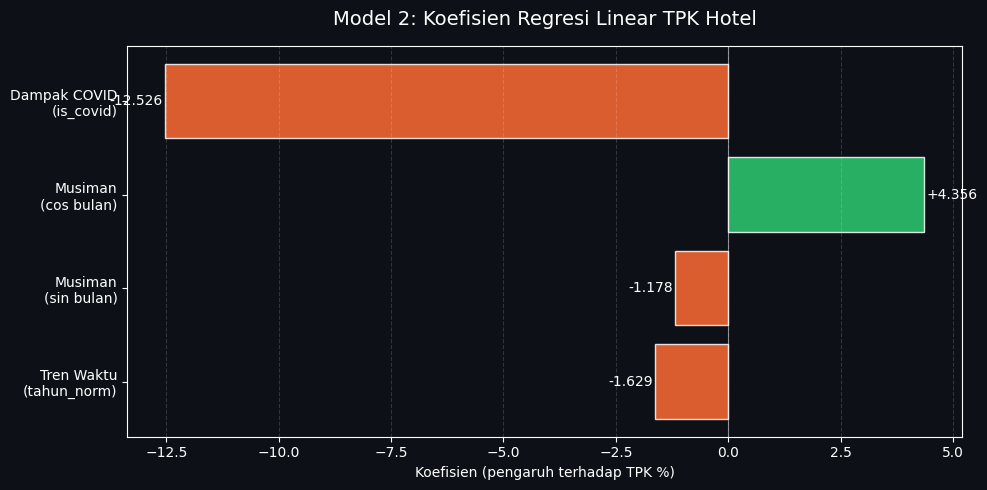

Saved: model2_reg_koefisien.png


In [12]:
# Visualisasi 2: Koefisien Regresi (kontribusi fitur)
label_map = {
    'tahun_norm' : 'Tren Waktu\n(tahun_norm)',
    'sin_bulan'  : 'Musiman\n(sin bulan)',
    'cos_bulan'  : 'Musiman\n(cos bulan)',
    'is_covid_int': 'Dampak COVID\n(is_covid)'
}
labels = [label_map[f] for f in FEAT_COLS_2]
colors = [GREEN_COLOR if c >= 0 else ACCENT_COLOR for c in reg.coef_]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(labels, reg.coef_, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, reg.coef_):
    xpos = val + (0.05 if val >= 0 else -0.05)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=10, color='white')

ax.set_title('Model 2: Koefisien Regresi Linear TPK Hotel', fontsize=14, pad=15)
ax.set_xlabel('Koefisien (pengaruh terhadap TPK %)')
ax.grid(True, axis='x', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model2_reg_koefisien.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: model2_reg_koefisien.png')

**Interpretasi Model 2 — Hasil Aktual:**

**Koefisien:**
| Fitur | Koefisien | Makna |
|-------|-----------|-------|
| `tahun_norm` | **−1.629** | TPK turun ~1.6 ppt per tahun sejak 2019 — menunjukkan pemulihan pasca-COVID belum kembali ke level pra-pandemi |
| `is_covid_int` | **−12.526** | Periode COVID menurunkan TPK rata-rata **12.5 poin persentase** per bulan |
| `cos_bulan` | **+4.356** | Efek musiman dominan: bulan Desember–Januari (cos tinggi) memiliki TPK lebih tinggi — konsisten dengan temuan eksplorasi peak bulan Desember |
| `sin_bulan` | **−1.178** | Bulan Maret–Juni (sin tinggi) sedikit lebih rendah — low season |

**Evaluasi:**
- **R² train = 0.513** — model menjelaskan ~51% variansi data latih; wajar untuk regresi linear sederhana dengan hanya 4 fitur
- **R² test = 0.107** — generalisasi ke 2025 rendah; dipicu anomali Maret 2025 (aktual 24.3% vs prediksi 36.6%) yang tidak tertangkap oleh model
- **RMSE = 4.50, MAE = 3.30** — rata-rata error prediksi sekitar 3–4.5 poin persentase TPK
- Model ini **bersifat eksplanatif** (menjelaskan faktor penentu TPK) lebih dari prediktif; untuk akurasi prediksi yang lebih tinggi diperlukan fitur tambahan atau model non-linear

---
## Ringkasan Evaluasi Model

In [13]:
import os

MODEL_RESULTS_DIR = '../outputs/model_results/'
os.makedirs(MODEL_RESULTS_DIR, exist_ok=True)

# Model 1 output: kawasan wisata alam hasil clustering
out1 = features1[['pengelola_kawasan', 'tipe_pengelola',
                   'avg_pengunjung', 'years_active', 'rasio_wisman', 'cluster']]
out1.to_csv(f'{MODEL_RESULTS_DIR}wisata_alam_clustered.csv', index=False)

# Model 2 output: prediksi vs aktual TPK hotel
out2 = pd.DataFrame({
    'tahun'    : list(train['tahun']) + list(test['tahun']),
    'bulan_num': list(train['bulan_num']) + list(test['bulan_num']),
    'tpk_aktual'  : list(y_train) + list(y_test),
    'tpk_prediksi': list(y_pred_train) + list(y_pred_test),
    'split'    : ['train'] * len(train) + ['test'] * len(test)
})
out2.to_csv(f'{MODEL_RESULTS_DIR}hotel_tpk_predicted.csv', index=False)

print('Output disimpan ke outputs/model_results/:')
print(f'  wisata_alam_clustered.csv  ({len(out1)} kawasan)')
print(f'  hotel_tpk_predicted.csv    ({len(out2)} baris)')

Output disimpan ke outputs/model_results/:
  wisata_alam_clustered.csv  (71 kawasan)
  hotel_tpk_predicted.csv    (84 baris)


In [15]:
print('RINGKASAN EVALUASI MODEL')

print(f'\n[Model 1] K-Means — Kawasan Wisata Alam')
print(f'  Metode       : K-Means Clustering')
print(f'  Dataset      : dishut_clean_v2.csv (tahun normal: 2016–2019, 2021)')
print(f'  Fitur        : avg_pengunjung, years_active, rasio_wisman, tipe_pengelola')
print(f'  Jumlah data  : {len(features1)} kawasan aktif')
print(f'  k            : {K1}')
print(f'  Silhouette   : {sil1:.4f}')
dist1 = features1["cluster"].value_counts().sort_index().to_dict()
print(f'  Distribusi   : {dist1}')

print(f'\n[Model 2] Regresi Linear — TPK Hotel Jawa Barat')
print(f'  Metode       : Linear Regression (temporal split)')
print(f'  Dataset      : hotel_scrubbed.csv (2019–2025)')
print(f'  Fitur        : tahun_norm, sin_bulan, cos_bulan, is_covid')
print(f'  Train/Test   : 2019–2024 ({len(train)} bln) / 2025 ({len(test)} bln)')
print(f'  R² (train)   : {r2_train:.4f}')
print(f'  R² (test)    : {r2_test:.4f}')
print(f'  RMSE (test)  : {rmse_test:.4f}')
print(f'  MAE  (test)  : {mae_test:.4f}')

print(f'\nOutput tersimpan di: outputs/model_results/')
print(f'\nCatatan interpretasi silhouette score:')
print(f'  0.25 - 0.50  : struktur lemah')
print(f'  0.50 - 0.70  : struktur reasonable')
print(f'  > 0.70       : struktur kuat')
print(f'\nCatatan interpretasi R²:')
print(f'  > 0.70       : model cukup baik')
print(f'  > 0.85       : model sangat baik')

RINGKASAN EVALUASI MODEL

[Model 1] K-Means — Kawasan Wisata Alam
  Metode       : K-Means Clustering
  Dataset      : dishut_clean_v2.csv (tahun normal: 2016–2019, 2021)
  Fitur        : avg_pengunjung, years_active, rasio_wisman, tipe_pengelola
  Jumlah data  : 71 kawasan aktif
  k            : 4
  Silhouette   : 0.6686
  Distribusi   : {0: 45, 1: 13, 2: 5, 3: 8}

[Model 2] Regresi Linear — TPK Hotel Jawa Barat
  Metode       : Linear Regression (temporal split)
  Dataset      : hotel_scrubbed.csv (2019–2025)
  Fitur        : tahun_norm, sin_bulan, cos_bulan, is_covid
  Train/Test   : 2019–2024 (72 bln) / 2025 (12 bln)
  R² (train)   : 0.5133
  R² (test)    : 0.1066
  RMSE (test)  : 4.4965
  MAE  (test)  : 3.3049

Output tersimpan di: outputs/model_results/

Catatan interpretasi silhouette score:
  0.25 - 0.50  : struktur lemah
  0.50 - 0.70  : struktur reasonable
  > 0.70       : struktur kuat

Catatan interpretasi R²:
  > 0.70       : model cukup baik
  > 0.85       : model sangat 